# Multi-Agent Framework for Semantic Discovery and GraphRAG
## Interactive Demonstration

This notebook provides a step-by-step demonstration of the multi-agent pipeline.

### Pipeline

| Section | Purpose |
|---------|----------|
| 1 | Configuration |
| 2 | Environment check |
| 3 | Data loading |
| 4 | Builder Graph |
| 5 | Graph inspection |
| 6 | Query Graph |
| 7 | Cleanup |

### Prerequisites

Neo4j running on port 7687. LM Studio running on port 1234 with a model loaded.  configured with  and .


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from scripts.neo4j_lifecycle import start_neo4j

start_neo4j()  # starts / resumes container; registers stop_neo4j() on kernel exit

✅ Neo4j already running  (bolt://localhost:7687)


---
## Section 1 — Configuration

All settings are defined here. Modify this cell before running the rest of the notebook.


In [2]:
from pathlib import Path

# ── Data paths ─────────────────────────────────────────────────────────────────
DATA_DIR = (Path.cwd().parent / "tests" / "fixtures").resolve()

# Full fixtures (complete run):
DOC_PATHS = [
    DATA_DIR / "00_legacy" / "sample_docs" / "business_glossary.txt",
    DATA_DIR / "00_legacy" / "sample_docs" / "data_dictionary.txt",
]
DDL_PATHS = [DATA_DIR / "00_legacy" / "sample_ddl" / "complex_schema.sql"]

# ── LLM model selection ────────────────────────────────────────────────────────
# Reasoning LLM: used for mapping, critic, ER judge, Cypher gen/healing
LLM_MODEL_REASONING = "openai/gpt-oss-120b"

# Extraction SLM: used for triplet extraction from PDF/text chunks
LLM_MODEL_EXTRACTION = "openai/gpt-4.1-nano"   # LM Studio local

# API keys (only needed for the providers you actually use above)
OPENROUTER_API_KEY = ""     # Required when using OpenRouter models (provider/model format)
# OPENAI_API_KEY   = ""     # Required for OpenAI direct ("gpt-*", "o1-*")
# ANTHROPIC_API_KEY = ""    # Required for Anthropic direct ("claude-*")

# Token budgets
LLM_MAX_TOKENS_REASONING  = 16384   # Caps thinking+output on reasoning LLM (avoids empty responses)
LLM_MAX_TOKENS_EXTRACTION = 8192    # Caps JSON output on extraction SLM (lower = fewer truncations)

TEMPERATURE_EXTRACTION = 0.0
TEMPERATURE_REASONING  = 0.0
TEMPERATURE_GENERATION = 0.3

# LM Studio endpoint (ignored when EXTRACTION model is not a local model)
LMSTUDIO_BASE_URL = "http://localhost:1234/v1"

# ── Neo4j ──────────────────────────────────────────────────────────────────────
NEO4J_URI      = "bolt://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "test_password"

# ── Entity resolution ──────────────────────────────────────────────────────────
ER_BLOCKING_TOP_K       = 10
ER_SIMILARITY_THRESHOLD = 0.75

# ── Retrieval ──────────────────────────────────────────────────────────────────
RETRIEVAL_MODE         = "hybrid"
RETRIEVAL_VECTOR_TOP_K = 20
RETRIEVAL_BM25_TOP_K   = 10
RETRIEVAL_GRAPH_DEPTH  = 2
RERANKER_TOP_K         = 5

# ── Thresholds ─────────────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD        = 0.90
MAX_REFLECTION_ATTEMPTS     = 3
MAX_CYPHER_HEALING_ATTEMPTS = 3
MAX_HALLUCINATION_RETRIES   = 3
EXTRACTION_CONCURRENCY      = 10

# ── Ablation flags ─────────────────────────────────────────────────────────────
ENABLE_SCHEMA_ENRICHMENT    = True
ENABLE_CYPHER_HEALING       = True
ENABLE_CRITIC_VALIDATION    = True
ENABLE_RERANKER             = True
ENABLE_HALLUCINATION_GRADER = True

# ── Logging ────────────────────────────────────────────────────────────────────
LOG_LEVEL = "INFO"      # INFO (pipeline events) | WARNING (quiet) | DEBUG (full trace)

# ── Summary ────────────────────────────────────────────────────────────────────
from src.config.llm_factory import detect_provider
_r_provider = detect_provider(LLM_MODEL_REASONING)
_e_provider = detect_provider(LLM_MODEL_EXTRACTION)
print("Configuration loaded.")
print(f"  Reasoning  : {LLM_MODEL_REASONING!r}  →  provider={_r_provider}  max_tokens={LLM_MAX_TOKENS_REASONING}")
print(f"  Extraction : {LLM_MODEL_EXTRACTION!r}  →  provider={_e_provider}  max_tokens={LLM_MAX_TOKENS_EXTRACTION}")
print(f"  Documents  : {len(DOC_PATHS)} file(s)")
print(f"  DDL files  : {len(DDL_PATHS)} file(s)")
print(f"  Neo4j      : {NEO4J_URI}")

c:\Users\ma.lopez\Documents\github\thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration loaded.
  Reasoning  : 'openai/gpt-oss-120b'  →  provider=openrouter  max_tokens=16384
  Extraction : 'openai/gpt-4.1-nano'  →  provider=openrouter  max_tokens=8192
  Documents  : 2 file(s)
  DDL files  : 1 file(s)
  Neo4j      : bolt://localhost:7687


---
## Section 2 — Environment Check

Verify that Neo4j is reachable and the LM Studio server is responding.


In [3]:
import sys, os
import requests

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

# Push all config into environment so Pydantic Settings picks them up
os.environ["NEO4J_URI"]                    = NEO4J_URI
os.environ["NEO4J_USER"]                   = NEO4J_USER
os.environ["NEO4J_PASSWORD"]               = NEO4J_PASSWORD
os.environ["LMSTUDIO_BASE_URL"]            = LMSTUDIO_BASE_URL
os.environ["LLM_MODEL_REASONING"]          = LLM_MODEL_REASONING
os.environ["LLM_MODEL_EXTRACTION"]         = LLM_MODEL_EXTRACTION
os.environ["LLM_MAX_TOKENS_EXTRACTION"]    = str(LLM_MAX_TOKENS_EXTRACTION)
os.environ["LLM_MAX_TOKENS_REASONING"]     = str(LLM_MAX_TOKENS_REASONING)
os.environ["LOG_LEVEL"]                    = LOG_LEVEL
os.environ["EXTRACTION_CONCURRENCY"]       = str(EXTRACTION_CONCURRENCY)
if OPENROUTER_API_KEY:
    os.environ["OPENROUTER_API_KEY"]       = OPENROUTER_API_KEY

# Clear cached LLM instances so they re-read the updated env vars
from src.config.llm_factory import reconfigure_from_env

reconfigure_from_env()

from src.config.logging import setup_notebook_logging

setup_notebook_logging()

from src.graph.neo4j_client import Neo4jClient

# Neo4j check
neo4j_ok = False
try:
    with Neo4jClient() as client:
        client.execute_cypher("RETURN 1")
    neo4j_ok = True
except Exception as exc:
    print(f"[FAIL] Neo4j: {exc}")

# LM Studio check (only when extraction model is local)
from src.config.llm_factory import detect_provider

lmstudio_ok = detect_provider(LLM_MODEL_EXTRACTION) == "lmstudio"  # skip if not local
model_ids = []
if lmstudio_ok:
    lmstudio_ok = False
    try:
        resp = requests.get(f"{LMSTUDIO_BASE_URL}/models", timeout=5)
        if resp.status_code == 200:
            model_ids = [m["id"] for m in resp.json().get("data", [])]
            lmstudio_ok = True
    except Exception as exc:
        print(f"[FAIL] LM Studio: {exc}")

print("Environment Check")
print("-" * 40)
print(f"Neo4j      : {'OK' if neo4j_ok else 'FAIL'}  ({NEO4J_URI})")
if detect_provider(LLM_MODEL_EXTRACTION) == "lmstudio":
    print(f"LM Studio  : {'OK' if lmstudio_ok else 'FAIL'}  ({LMSTUDIO_BASE_URL})")
    if model_ids:
        print(f"  Loaded models: {model_ids}")
else:
    print(f"LM Studio  : skipped (extraction uses {detect_provider(LLM_MODEL_EXTRACTION)})")
print("-" * 40)
if not neo4j_ok:
    print("Fix the issues above before proceeding.")
else:
    print("All required services are reachable.")


Environment Check
----------------------------------------
Neo4j      : OK  (bolt://localhost:7687)
LM Studio  : skipped (extraction uses openrouter)
----------------------------------------
All required services are reachable.


---
## Section 3 — Data Loading

Load and chunk source documents, then parse DDL files.


In [4]:
from src.ingestion.pdf_loader import load_pdf, chunk_documents
from src.ingestion.ddl_parser import parse_ddl

doc_paths = [DATA_DIR / f for f in DOC_PATHS]
ddl_paths = [DATA_DIR / f for f in DDL_PATHS]

all_chunks = []
for path in doc_paths:
    docs   = load_pdf(path)
    chunks = chunk_documents(docs)
    all_chunks.extend(chunks)

all_tables = []
for path in ddl_paths:
    ddl = path.read_text()
    all_tables.extend(parse_ddl(ddl))

print(f"Documents loaded : {len(doc_paths)} file(s)  ->  {len(all_chunks)} chunk(s)")
print(f"DDL files loaded : {len(ddl_paths)} file(s)  ->  {len(all_tables)} table(s)")
if all_chunks:
    print()
    print("First chunk preview:")
    print("-" * 40)
    print(all_chunks[0].text[:300])


15:52:36  ingestion.pdf_loader              Loaded text file 'business_glossary.txt'
15:52:36  ingestion.pdf_loader              Chunked 1 documents into 10 chunks (chunk_size=256, overlap=32)
15:52:36  ingestion.pdf_loader              Loaded text file 'data_dictionary.txt'
15:52:36  ingestion.pdf_loader              Chunked 1 documents into 29 chunks (chunk_size=256, overlap=32)
15:52:36  ingestion.ddl_parser              Parsed 8 table(s) from DDL input.


Documents loaded : 2 file(s)  ->  39 chunk(s)
DDL files loaded : 1 file(s)  ->  8 table(s)

First chunk preview:
----------------------------------------
BUSINESS GLOSSARY — E-COMMERCE DOMAIN

This document defines the core business concepts and their relationships in the e-commerce platform. These concepts represent the shared understanding between business stakeholders and technical teams.

───────────────


---
## Section 4 — Builder Graph

Orchestrates the full Knowledge Graph construction pipeline.

| Step | Component | Description |
|------|-----------|-------------|
| 1 | Triplet Extractor | Extract (subject, predicate, object) from text |
| 2 | Entity Resolver | Deduplicate entities: embedding blocking + LLM judge |
| 3 | DDL Parser | Parse SQL into typed table definitions |
| 4 | Schema Enricher | Expand abbreviated column names via LLM |
| 5 | RAG Mapper | Map each physical table to a business concept |
| 6 | Validator | Actor-Critic validation of mapping proposals |
| 7 | Cypher Generator | Generate MERGE statements for Neo4j |
| 8 | Cypher Healer | Auto-correct syntax errors via self-reflection |
| 9 | Graph Writer | Execute Cypher against Neo4j |

Self-reflection loops (via ) are active at steps 1, 2, 5, and 8.

### Node diagram




In [5]:
import time
import logging
from src.graph.builder_graph import run_builder

print("Running Builder Graph ...")


start = time.time()

final_state = run_builder(
    raw_documents=doc_paths,
    ddl_paths=ddl_paths,
    production=False,
    clear_graph=True,  # wipe stale data from prior demo runs
)

elapsed = time.time() - start

triplets  = final_state.get("triplets", [])
entities  = final_state.get("entities", [])
tables    = final_state.get("tables", [])
enriched  = final_state.get("enriched_tables", [])
completed = final_state.get("completed_tables", [])
failed    = final_state.get("cypher_failed", False)

print()
print("Builder Graph Results")
print("-" * 40)
print(f"Elapsed             : {elapsed:.1f} s")
print(f"Triplets extracted  : {len(triplets)}")
print(f"Entities resolved   : {len(entities)}")
print(f"Tables parsed       : {len(tables)}")
print(f"Tables enriched     : {len(enriched)}")
print(f"Tables completed    : {len(completed)}")
print(f"Cypher failures     : {failed}")
if completed:
    print()
    print("Completed tables:")
    for t in completed:
        print(f"  - {t}")


15:52:37  ingestion.pdf_loader              Loaded text file 'business_glossary.txt'
15:52:37  ingestion.pdf_loader              Chunked 1 documents into 10 chunks (chunk_size=256, overlap=32)
15:52:37  ingestion.pdf_loader              Loaded text file 'data_dictionary.txt'
15:52:37  ingestion.pdf_loader              Chunked 1 documents into 29 chunks (chunk_size=256, overlap=32)
15:52:37  graph.builder_graph               Graph cleared before builder run.


Running Builder Graph ...


15:52:46  llm.extraction                    llm.extraction call completed | attempt=1 | latency_ms=7563.2 | input_tokens=508 | output_tokens=582 | total_tokens=1090
15:52:46  extraction.triplet_extractor      Chunk 0 → 9 triplets extracted (source=business_glossary.txt, page=1)
15:52:47  llm.extraction                    llm.extraction call completed | attempt=1 | latency_ms=8535.9 | input_tokens=423 | output_tokens=656 | total_tokens=1079
15:52:47  extraction.triplet_extractor      Chunk 9 → 12 triplets extracted (source=business_glossary.txt, page=1)
15:52:48  llm.extraction                    llm.extraction call completed | attempt=1 | latency_ms=9767.6 | input_tokens=538 | output_tokens=742 | total_tokens=1280
15:52:48  extraction.triplet_extractor      Chunk 2 → 11 triplets extracted (source=business_glossary.txt, page=1)
15:52:50  llm.extraction                    llm.extraction call completed | attempt=1 | latency_ms=11402.0 | input_tokens=494 | output_tokens=943 | total_tokens=


Builder Graph Results
----------------------------------------
Elapsed             : 482.3 s
Triplets extracted  : 407
Entities resolved   : 142
Tables parsed       : 8
Tables enriched     : 8
Tables completed    : 8
Cypher failures     : False

Completed tables:
  - CUSTOMER_MASTER
  - TB_CATEGORY
  - TB_PRODUCT
  - CUST_ADDRESS
  - SALES_ORDER_HDR
  - ORDER_LINE_ITEM
  - INVENTORY
  - SYS_AUDIT_LOG


---
## Section 5 — Graph Inspection

Query the Knowledge Graph using Cypher to verify the built ontology.


In [6]:
from src.graph.neo4j_client import Neo4jClient

with Neo4jClient() as client:
    node_rows = client.execute_cypher(
        "MATCH (n) RETURN labels(n) AS labels, count(n) AS count ORDER BY count DESC"
    )
    print("Node counts")
    print("-" * 40)
    for r in node_rows:
        print(f"  {r['labels']}: {r['count']}")

    concept_rows = client.execute_cypher(
        "MATCH (c:BusinessConcept) RETURN c.name AS name LIMIT 20"
    )
    print()
    print("Business Concepts")
    print("-" * 40)
    for r in concept_rows:
        print(f"  {r['name']}")

    mapping_rows = client.execute_cypher("""
        MATCH (c:BusinessConcept)-[r:MAPPED_TO]->(t:PhysicalTable)
        RETURN c.name AS concept, t.table_name AS table,
               round(r.confidence * 100) AS pct
        ORDER BY r.confidence DESC
    """)
    print()
    print("Concept -> Table Mappings")
    print("-" * 40)
    for r in mapping_rows:
        print(f"  {r['concept']} -> {r['table']}  ({r['pct']}%)")


Node counts
----------------------------------------
  ['BusinessConcept']: 8
  ['PhysicalTable']: 8

Business Concepts
----------------------------------------
  Customer Master
  Category
  Product Master
  Customer Address
  SalesOrder
  Order Line Item
  Inventory count per product per warehouse
  System log table

Concept -> Table Mappings
----------------------------------------
  SalesOrder -> SALES_ORDER_HDR  (98.0%)
  Customer Master -> CUSTOMER_MASTER  (96.0%)
  Order Line Item -> ORDER_LINE_ITEM  (96.0%)
  Category -> TB_CATEGORY  (95.0%)
  Product Master -> TB_PRODUCT  (95.0%)
  Customer Address -> CUST_ADDRESS  (95.0%)
  Inventory count per product per warehouse -> INVENTORY  (95.0%)
  System log table -> SYS_AUDIT_LOG  (92.0%)


### Graph Visualization
Interactive pyvis rendering of the Knowledge Graph (drag, zoom, hover for details).

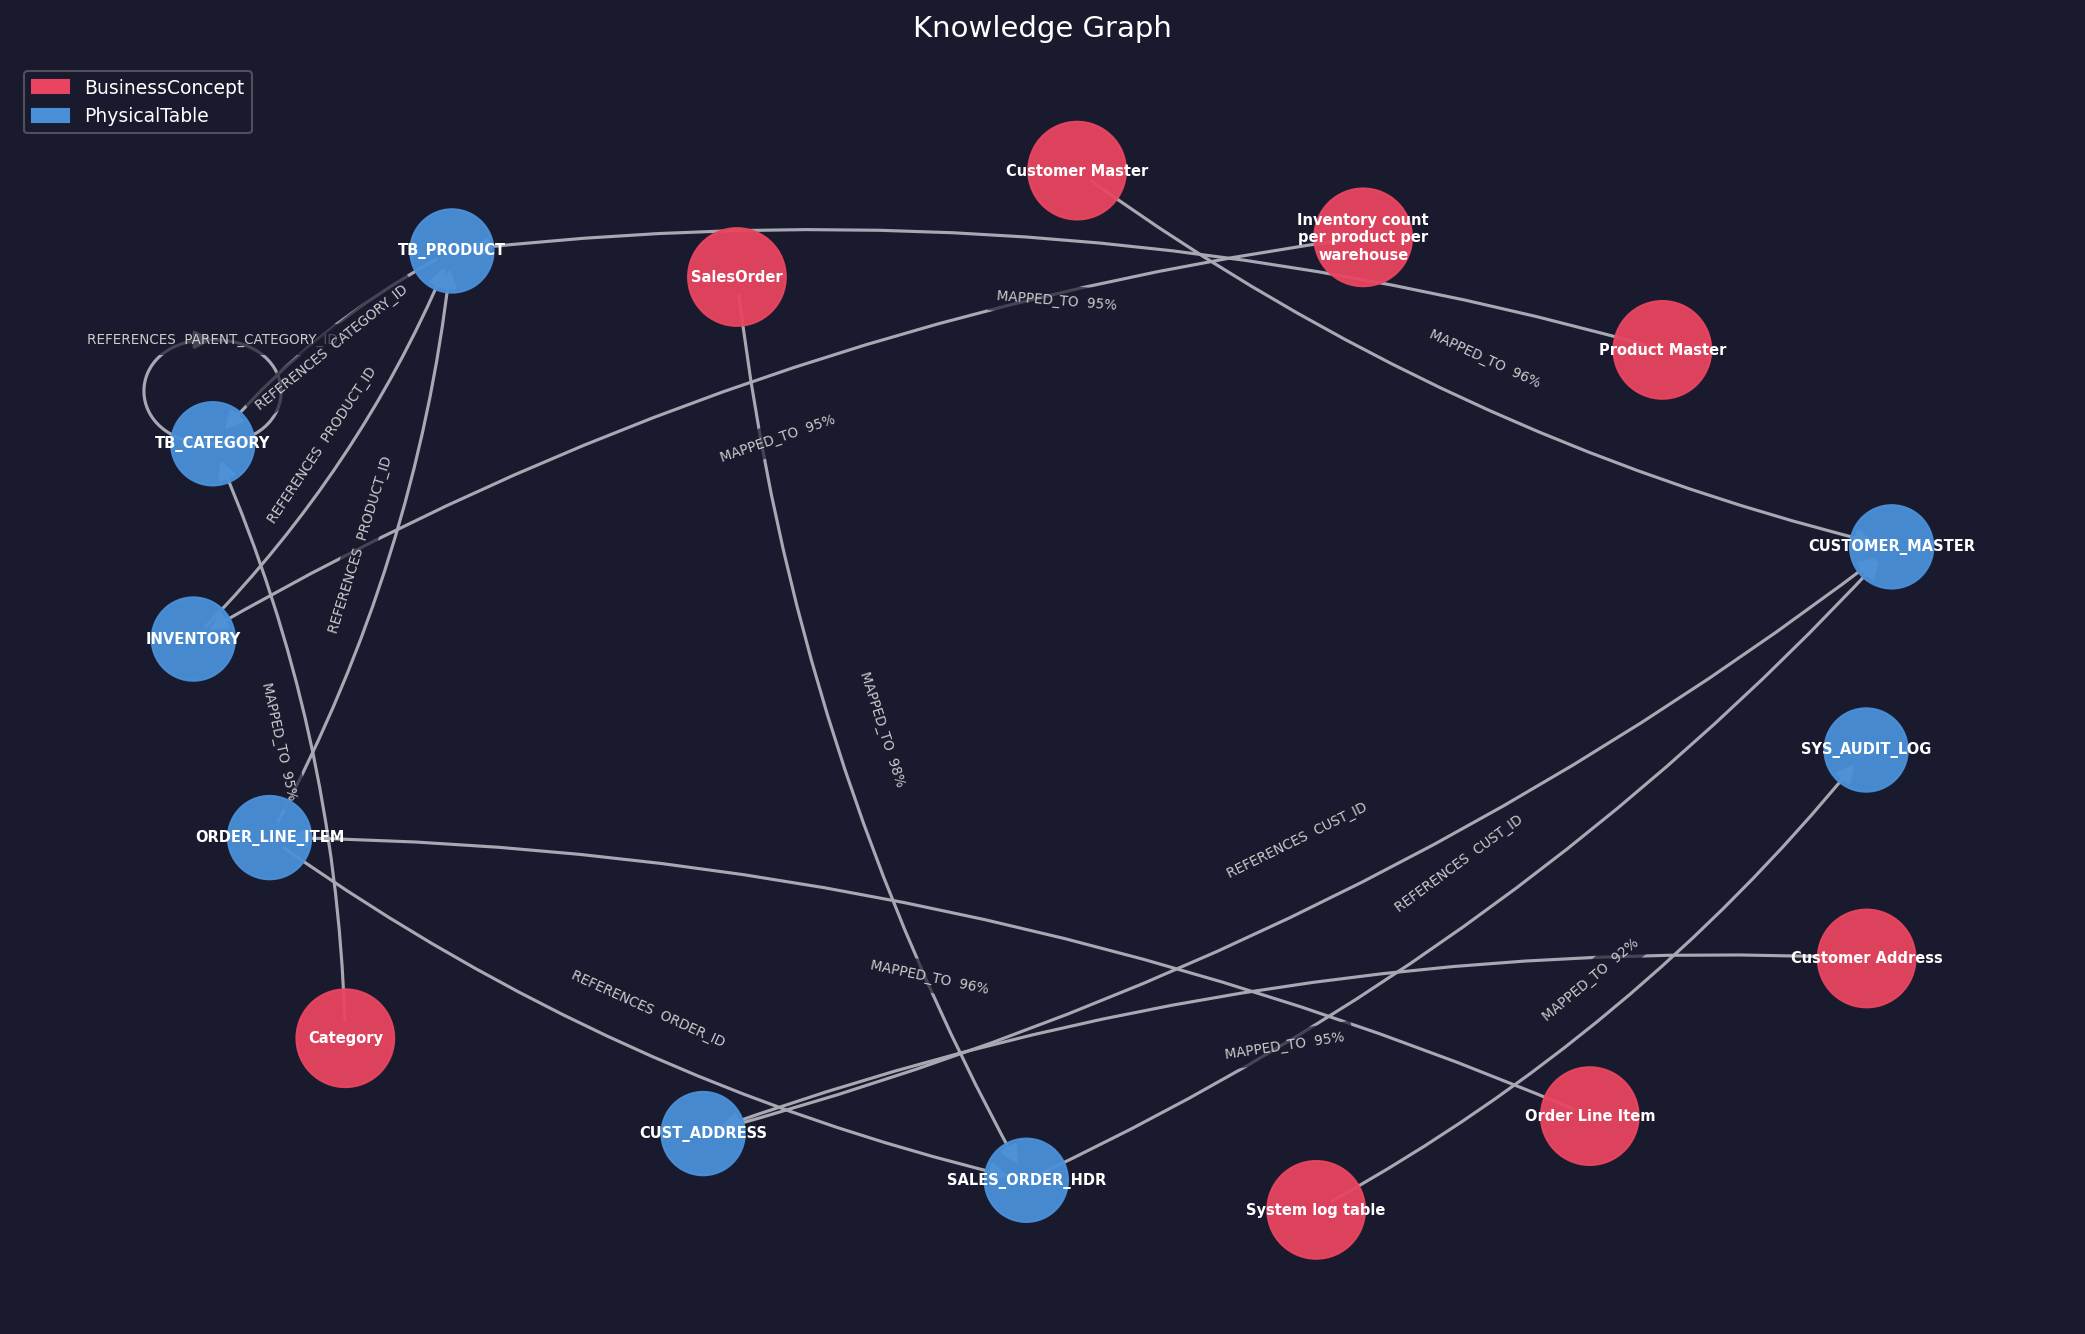

Saved to ../notebooks/kg_preview.png


In [7]:
import textwrap
import networkx as nx
import matplotlib
matplotlib.use('Agg')  # headless — works both in Jupyter and script mode
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
from src.graph.neo4j_client import Neo4jClient

# ── Fetch graph data from Neo4j ────────────────────────────────────────────
with Neo4jClient() as client:
    node_rows = client.execute_cypher(
        "MATCH (n) RETURN elementId(n) AS nid, labels(n) AS lbls, "
        "COALESCE(n.name, n.table_name, 'node') AS label"
    )
    edge_rows = client.execute_cypher(
        "MATCH (a)-[r]->(b) RETURN elementId(a) AS src, elementId(b) AS tgt, "
        "type(r) AS rel_type, COALESCE(r.confidence, r.column, '') AS prop"
    )

# ── Build networkx graph ───────────────────────────────────────────────────
G = nx.DiGraph()
node_labels, node_types = {}, {}
for r in node_rows:
    nid  = r['nid']
    lbl  = r['lbls'][0] if r['lbls'] else 'Unknown'
    name = '\n'.join(textwrap.wrap(r['label'], 16))
    G.add_node(nid)
    node_labels[nid] = name
    node_types[nid]  = lbl

edge_labels = {}
for r in edge_rows:
    G.add_edge(r['src'], r['tgt'])
    prop = r['prop']
    prop_str = f'{prop:.0%}' if isinstance(prop, float) else (str(prop) if prop else '')
    edge_labels[(r['src'], r['tgt'])] = f"{r['rel_type']}{'  '+prop_str if prop_str else ''}"

# ── Layout & colours ───────────────────────────────────────────────────────
_COLORS = {'BusinessConcept': '#e94560', 'PhysicalTable': '#4a90d9', 'default': '#7b5ea7'}
node_colors = [_COLORS.get(node_types.get(n, 'default'), _COLORS['default']) for n in G.nodes()]
node_sizes  = [2200 if node_types.get(n) == 'BusinessConcept' else 1600 for n in G.nodes()]

pos = nx.spring_layout(G, k=2.5, seed=42)

# ── Draw ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.95, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7,
                        font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#a8a8b3', arrows=True,
                       arrowsize=18, width=1.5,
                       connectionstyle='arc3,rad=0.1', ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6.5,
                              font_color='#cccccc', bbox=dict(fc='#1a1a2e', ec='none', alpha=0.7),
                              ax=ax)

# Legend
legend = [
    mpatches.Patch(color='#e94560', label='BusinessConcept'),
    mpatches.Patch(color='#4a90d9', label='PhysicalTable'),
]
ax.legend(handles=legend, loc='upper left', framealpha=0.3,
          labelcolor='white', facecolor='#1a1a2e', fontsize=9)
ax.set_title('Knowledge Graph', color='white', fontsize=14, pad=12)
ax.axis('off')
plt.tight_layout()

out_png = '../notebooks/kg_preview.png'
fig.savefig(out_png, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close(fig)
display(Image(filename=out_png))
print(f'Saved to {out_png}')

---
## Section 6 — Query Graph

Answer natural-language questions using the Knowledge Graph.

| Step | Component | Description |
|------|-----------|-------------|
| 1 | Hybrid Retriever | Dense + BM25 + Graph, fused via Reciprocal Rank Fusion |
| 2 | Cross-Encoder Reranker | Re-scores chunks for precision |
| 3 | Answer Generator | LLM generates grounded answer |
| 4 | Hallucination Grader | Self-RAG audit; retries with critique if needed |

### Node diagram




In [8]:
from src.generation.query_graph import run_query

user_query = "Which table stores customer data and what columns does it have?"

print(f"Query: {user_query}")
print()

result = run_query(user_query)

print("Answer")
print("-" * 40)
print(result.get("final_answer", "No answer generated."))


Query: Which table stores customer data and what columns does it have?



16:00:41  retrieval.reranker                Loading reranker model 'BAAI/bge-reranker-large'...
16:00:43  retrieval.reranker                Reranker model loaded.
16:00:48  retrieval.reranker                rerank: top chunk 'Customer Master' score=0.7384 (pool=18, top_k=10).
16:00:51  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=2711.8 | input_tokens=878 | output_tokens=169 | total_tokens=1047
16:00:51  generation.answer_generator       Answer generated (194 chars).
16:00:53  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=2184.3 | input_tokens=1069 | output_tokens=166 | total_tokens=1235
16:00:53  generation.hallucination_grader   Grader verdict: grounded=True, action=pass, critique=''.


Answer
----------------------------------------
The **Customer Master** table stores the customer data. It includes the primary‑key column **CUST_ID** and the following columns: **FULL_NAME**, **EMAIL**, **REGION_CODE**, and **IS_ACTIVE**【1】.


In [9]:
test_questions = [
    "What entities exist in the business domain?",
    "Which table stores customer information?",
    "How are customers and orders related?",
]

print("Batch Query Results")
print("=" * 60)
for i, question in enumerate(test_questions, 1):
    result = run_query(question)
    answer = result.get("final_answer", "")
    if len(answer) > 300:
        answer = answer[:300] + " [truncated]"
    print(f"[{i}/{len(test_questions)}] {question}")
    print(f"    {answer}")
    print()

Batch Query Results


16:00:58  retrieval.reranker                rerank: top chunk 'Customer Master' score=0.0091 (pool=18, top_k=10).
16:01:02  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=4215.3 | input_tokens=737 | output_tokens=138 | total_tokens=875
16:01:02  generation.answer_generator       Answer generated (179 chars).
16:01:05  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=3239.8 | input_tokens=925 | output_tokens=168 | total_tokens=1093
16:01:05  generation.hallucination_grader   Grader verdict: grounded=True, action=pass, critique=''.


[1/3] What entities exist in the business domain?
    The business domain includes the following entities: Customer Master, SalesOrder, System log table, Product Master, and Category.【1†source】【2†source】【3†source】【5†source】【6†source】



16:01:10  retrieval.reranker                rerank: top chunk 'Customer Address' score=0.9550 (pool=18, top_k=10).
16:01:14  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=4247.9 | input_tokens=762 | output_tokens=135 | total_tokens=897
16:01:14  generation.answer_generator       Answer generated (81 chars).
16:01:20  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=5648.9 | input_tokens=931 | output_tokens=215 | total_tokens=1146
16:01:20  generation.hallucination_grader   Grader verdict: grounded=True, action=pass, critique=''.


[2/3] Which table stores customer information?
    The CUSTOMER_MASTER table stores the core customer information.【2†L1-L3】【8†L1-L1】



16:01:24  retrieval.reranker                rerank: top chunk '' score=0.0110 (pool=18, top_k=10).
16:01:27  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=2774.9 | input_tokens=784 | output_tokens=207 | total_tokens=991
16:01:27  generation.answer_generator       Answer generated (317 chars).
16:01:29  llm.reasoning                     llm.reasoning call completed | attempt=1 | latency_ms=2509.4 | input_tokens=1000 | output_tokens=251 | total_tokens=1251
16:01:30  generation.hallucination_grader   Grader verdict: grounded=True, action=pass, critique=''.


[3/3] How are customers and orders related?
    Customers are stored in the **CUSTOMER_MASTER** (Customer Master) table, and orders are stored in the **SALES_ORDER_HDR** (SalesOrder) table. The **SALES_ORDER_HDR** table has a foreign‑key column **CUST_ID** that references **CUSTOMER_MASTER.CUST_ID**, linking each order record to the corresponding [truncated]



---
## Section 7 — Cleanup

Delete all nodes from the Knowledge Graph to reset the environment.


In [10]:
# WARNING: this permanently deletes all graph data.
# Uncomment and run to reset.

# from src.graph.neo4j_client import Neo4jClient
# with Neo4jClient() as client:
#     client.execute_cypher("MATCH (n) DETACH DELETE n")
# print("Knowledge Graph cleared.")

print("Cleanup cell ready. Uncomment the code above to delete the graph.")

Cleanup cell ready. Uncomment the code above to delete the graph.


---
## Summary

| Phase | Input | Output |
|-------|-------|--------|
| Builder Graph | Documents + DDL | Knowledge Graph in Neo4j |
| Query Graph | Natural-language question | Grounded answer |

**Next steps:**
- Replace smoke fixtures with your own documents in Section 1
- Toggle ablation flags to compare pipeline variants
- Explore the graph at http://localhost:7474

**Documentation:** 


In [11]:
#"""
from src.graph.neo4j_client import Neo4jClient

with Neo4jClient() as client:
    client.execute_cypher("MATCH (n) DETACH DELETE n")
print("Knowledge Graph cleared.")
#"""

Knowledge Graph cleared.
